# Activity 1.3 - Kernel Density Estimation (KDE)

**Seminario de Ciencia de Datos - Eliezer Lagunes Portela**

Dataset: `taxis` (Seaborn). Only numerical variables are used, as requested.
The KDE gives a non-parametric estimate of the probability density function.
Insights are given as comments at the end of the notebook.

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

taxis = sns.load_dataset("taxis")
taxis.info() #Check the data types of the columns

<class 'pandas.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[us]
 1   dropoff          6433 non-null   datetime64[us]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   str           
 9   payment          6389 non-null   str           
 10  pickup_zone      6407 non-null   str           
 11  dropoff_zone     6388 non-null   str           
 12  pickup_borough   6407 non-null   str           
 13  dropoff_borough  6388 non-null   str           
dtypes: datetime64[us](2), float64(5), int64(1), str(6)


In [2]:
#Keep the numerical variables only, as the activity requires
num = taxis.select_dtypes(include=[np.number])
print("Numerical variables", list(num.columns))
num.describe()

Numerical variables ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']


,passengers,distance,fare,tip,tolls,total
count,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
std,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570
min,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000


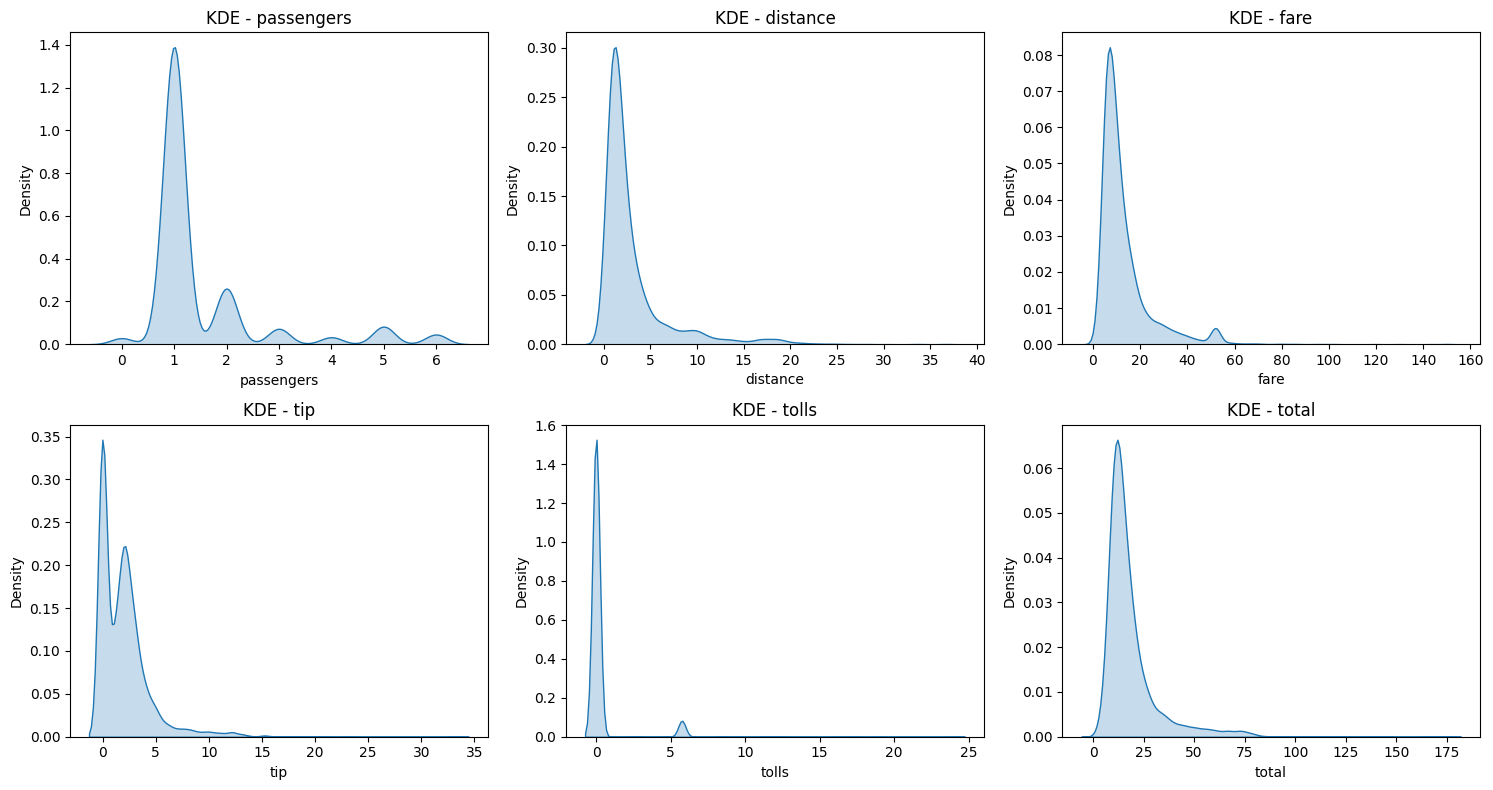

In [3]:
#KDE for every numerical variable
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num.columns):
    sns.kdeplot(data=num, x=col, fill=True, ax=ax)
    ax.set_title("KDE - " + col)
plt.tight_layout()
plt.show()

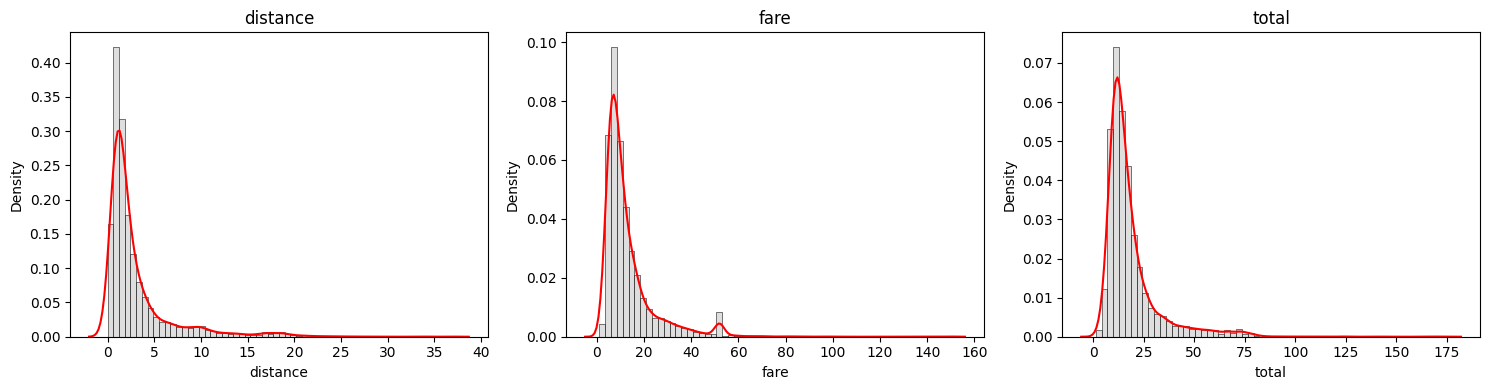

In [4]:
#Compare the KDE against the histogram to check that the estimate is reasonable
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["distance", "fare", "total"]):
    sns.histplot(data=num, x=col, bins=60, stat="density", color="lightgray", ax=ax)
    sns.kdeplot(data=num, x=col, color="red", ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

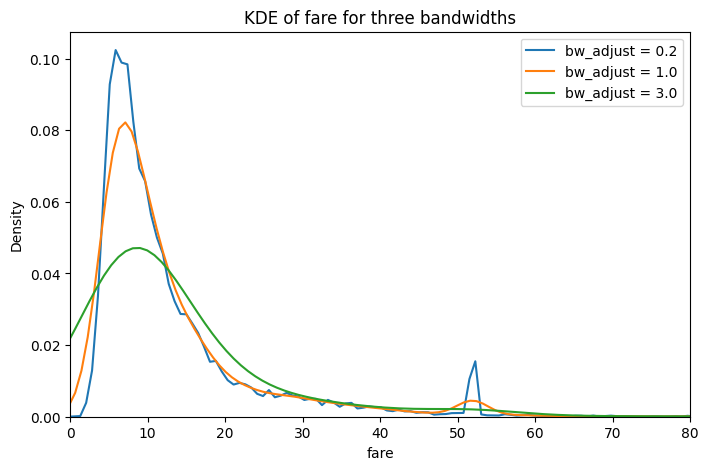

In [5]:
#Effect of the bandwidth on the estimate of the density of "fare"
plt.figure(figsize=(8, 5))
for b in [0.2, 1.0, 3.0]:
    sns.kdeplot(data=num, x="fare", bw_adjust=b, label="bw_adjust = " + str(b))
plt.xlim(0, 80)
plt.legend()
plt.title("KDE of fare for three bandwidths")
plt.show()

In [6]:
#Numerical summary of every estimated density: mode of the KDE, mean, median and skewness
from scipy.stats import gaussian_kde, skew

resumen = []
for col in num.columns:
    x = num[col].dropna()
    kde = gaussian_kde(x)
    malla = np.linspace(x.min(), x.max(), 2000)
    densidad = kde(malla)
    resumen.append({"variable": col,
                    "moda_KDE": malla[np.argmax(densidad)],
                    "media": x.mean(),
                    "mediana": x.median(),
                    "sesgo": skew(x),
                    "porcentaje_ceros": 100 * (x == 0).mean()})

resumen = pd.DataFrame(resumen).round(3)
resumen

,variable,moda_KDE,media,mediana,sesgo,porcentaje_ceros
0,passengers,0.999,1.539,1.00,2.359,1.492
1,distance,1.193,3.025,1.64,3.008,0.793
2,fare,7.038,13.091,9.50,3.217,0.000
3,tip,0.017,1.979,1.70,2.665,35.924
4,tolls,0.000,0.325,0.00,5.074,94.559
5,total,11.977,18.518,14.16,3.093,0.000


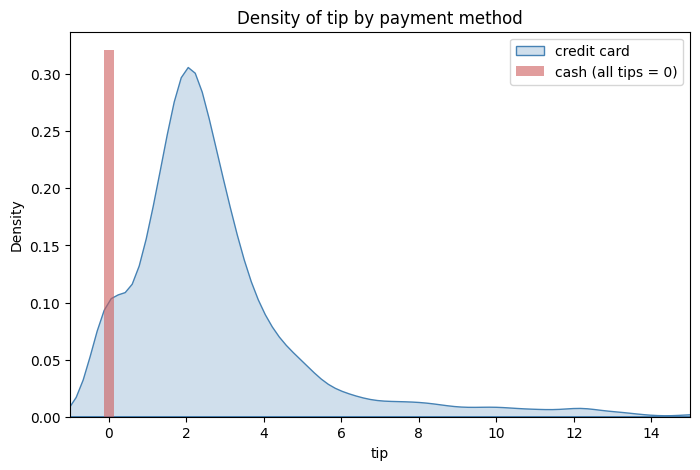

Proportion of trips with tip = 0 by payment method
payment
cash           1.000
credit card    0.099
Name: tip, dtype: float64
Variance of tip for cash 0.0


In [7]:
#The KDE of "tip" has a spike at zero. Split it by payment method to explain it.
#The cash group has zero variance (every cash trip is registered with tip = 0),
#so its density cannot be estimated and it is shown as a bar instead
efectivo = taxis[taxis["payment"] == "cash"]["tip"]
tarjeta = taxis[taxis["payment"] == "credit card"]["tip"]

plt.figure(figsize=(8, 5))
sns.kdeplot(x=tarjeta, fill=True, color="steelblue", label="credit card")
plt.bar(0, plt.ylim()[1], width=0.25, color="indianred", alpha=0.6, label="cash (all tips = 0)")
plt.xlim(-1, 15)
plt.xlabel("tip")
plt.legend()
plt.title("Density of tip by payment method")
plt.show()

print("Proportion of trips with tip = 0 by payment method")
print(taxis.groupby("payment")["tip"].apply(lambda s: (s == 0).mean()).round(3))
print("Variance of tip for cash", round(efectivo.var(), 6))

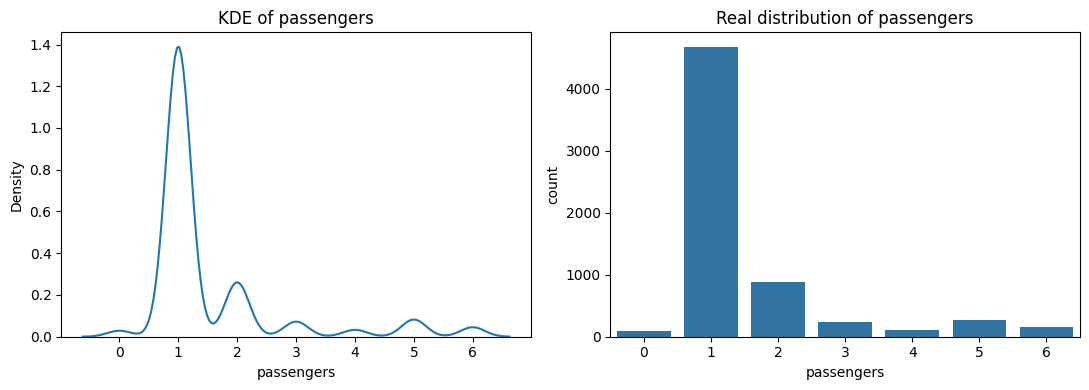

Values of passengers
passengers
0      96
1    4678
2     876
3     243
4     110
5     277
6     153
Name: count, dtype: int64


In [8]:
#"passengers" is a discrete variable. The KDE smooths it and invents density between the integers
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.kdeplot(data=num, x="passengers", ax=axes[0])
axes[0].set_title("KDE of passengers")
sns.countplot(data=taxis, x="passengers", ax=axes[1])
axes[1].set_title("Real distribution of passengers")
plt.tight_layout()
plt.show()

print("Values of passengers")
print(taxis["passengers"].value_counts().sort_index())

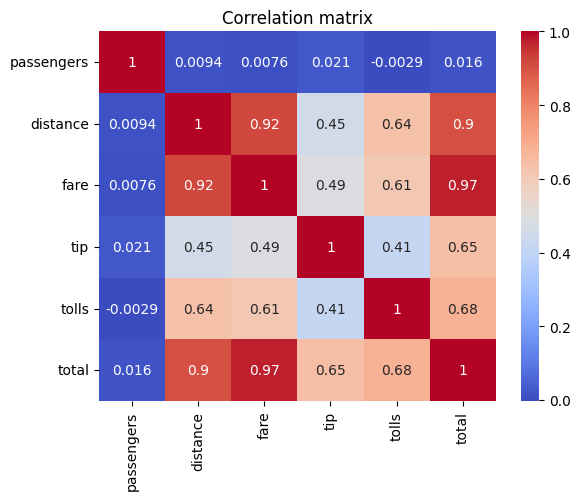

In [9]:
#Correlation between the numerical variables, to see why some densities have the same shape
correlacion = num.corr()
sns.heatmap(correlacion, annot=True, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

In [10]:
#INSIGHTS

#Insight 1. All the numerical variables have one peak and a long tail to the right.
#The mode of the KDE is always lower than the mean. For fare the mode is 7.04 and the
#mean is 13.09. For distance the mode is 1.19 and the mean is 3.03. Most trips are short
#and cheap, but a few very long ones pull the mean up. The longest trip is 36.7 miles
#and the most expensive one is 150 dollars.

#Insight 2. The KDE of "tip" is the only one with two peaks, one at zero and one around
#2 dollars. I split the density by payment method to see why. All the cash trips have
#tip = 0 and only 9.9 percent of the credit card trips do. So the peak at zero is not
#because people do not tip. The meter just does not record the cash tips.

#Insight 3. The KDE does not work well for two of the six variables. "passengers" is
#discrete and only takes values from 0 to 6, so the density gives probability to numbers
#like 1.5 passengers, which cannot happen. "tolls" is 94.6 percent zeros, so it is almost
#all one point at zero with a very thin tail. No bandwidth fixes that shape.

#Insight 4. distance, fare and total have almost the same shape because they measure the
#same thing. The correlation between fare and total is 0.974 and between distance and
#fare is 0.920. Doing the three KDEs separately does not add much information.

#Insight 5. The bandwidth changes the result a lot. With bw_adjust = 0.2 the KDE of fare
#gets small spikes, because the fares are rounded to whole dollars. With bw_adjust = 3.0
#the peak at 7 dollars disappears and the curve looks almost symmetric. The default value
#of Seaborn is the one that follows the histogram best.